# Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

df = pd.read_csv('data/labels.csv')
df.head()


,image,age,gender,gender_name,race,race_name
0,100_0_0_20170112213500903.jpg.chip.jpg,100,0,Male,0,white
1,100_0_0_20170112215240346.jpg.chip.jpg,100,0,Male,0,white
2,100_1_0_20170110183726390.jpg.chip.jpg,100,1,Female,0,white
3,100_1_0_20170112213001988.jpg.chip.jpg,100,1,Female,0,white
4,100_1_0_20170112213303693.jpg.chip.jpg,100,1,Female,0,white


In [9]:
print(f"Number of samples: {len(df)}")

Number of samples: 23705


## Histograms

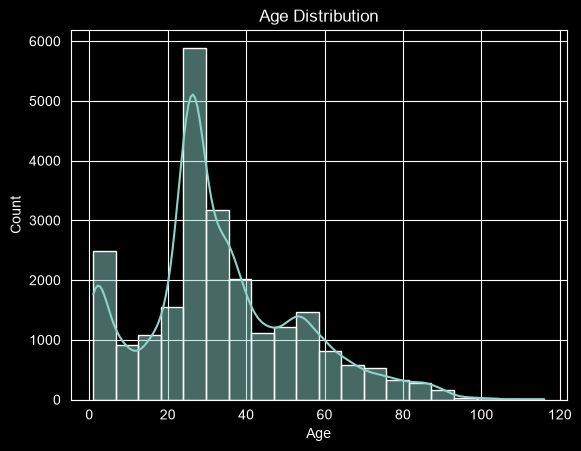

In [32]:
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


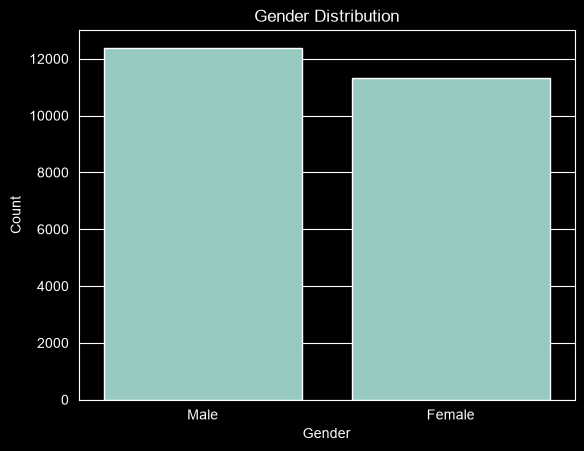

In [33]:
sns.countplot(data=df, x="gender_name")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


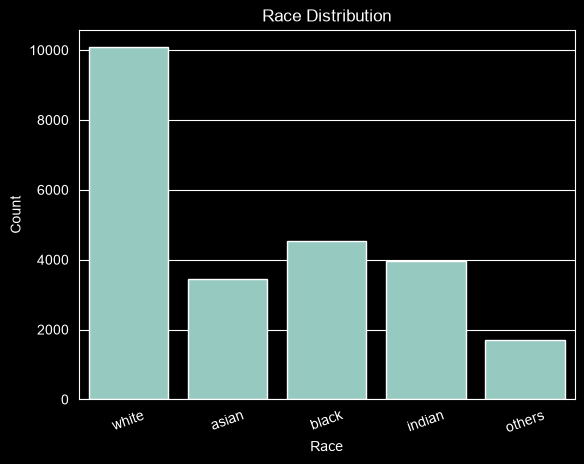

In [34]:
sns.countplot(data=df, x="race_name")
plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


## Image Samples

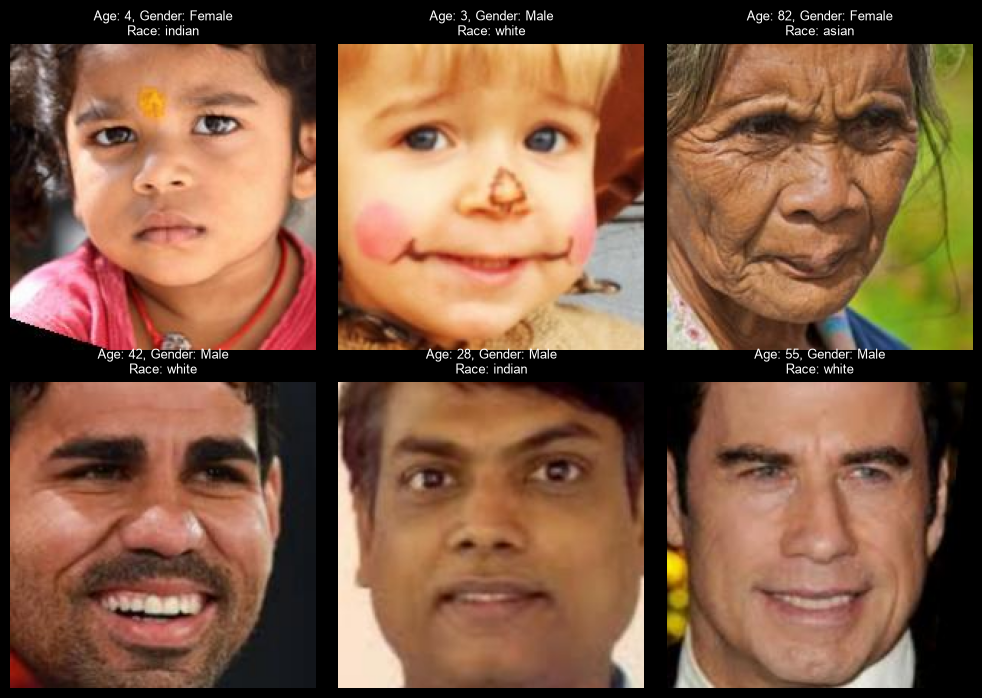

In [38]:
image_dir = Path("data/images")
n_images = 6

sample_df = df.sample(n=min(n_images, len(df)), random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()
for plot_idx, (_, row) in enumerate(sample_df.iterrows()):
	image_path = image_dir / row["image"]
	with Image.open(image_path) as img:
		image = img.convert("RGB")
	axes[plot_idx].imshow(image)
	axes[plot_idx].set_title(
		f"Age: {row['age']}, Gender: {row['gender_name']}\nRace: {row['race_name']}",
		fontsize=9,
	)
	axes[plot_idx].axis("off")
for extra_idx in range(len(sample_df), len(axes)):
	axes[extra_idx].axis("off")
plt.tight_layout()
plt.show()

